<a href="https://colab.research.google.com/github/masonsears/-Data-Processing-Visualization-CPSMA-4313-01-projects/blob/Projects/ProjectCreateDataMasonSears.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Mason Sears
Data Processing Visualization CPSMA-4313-01
April 9th 2026

**Overwatch Character Statistics and Information**

In [ ]:
%pip install google-colab-selenium

In [2]:
import google_colab_selenium as gs
from selenium.webdriver.chrome.options import Options

chrome_options = Options()
chrome_options.add_argument('--headless')
chrome_options.add_argument('--no-sandbox')
chrome_options.add_argument('--disable-dev-shm-usage')
chrome_options.add_argument('user-agent=Chrome/146')
chrome_options.add_argument('--incognito')
chrome_options.add_argument('--window-size=1920,1080')

driver = gs.Chrome(options=chrome_options)
driver.set_page_load_timeout(120)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

These chrome options help selenium bypass the cloudfare protection on fandom wiki.

In [3]:
import requests
import re
import json
import pandas as pa
from bs4 import BeautifulSoup

headers = {'User-Agent': 'chrome/146'}
r = requests.get('https://overwatch.blizzard.com/en-us/rates/?input=PC&map=all-maps&region=Americas&role=All&rq=2&tier=All', headers=headers)
html_contents = r.text
html_soup = BeautifulSoup(html_contents,"lxml")

In [4]:
tables = html_soup.find_all('blz-data-table')
len(tables)

1

In [5]:
from IPython.display import display

if tables:
    allrows_json_str = tables[0].get('allrows')

    if allrows_json_str:
        try:
            data = json.loads(allrows_json_str)

            rows_for_df = []
            for item in data:
                hero_data = {
                    'name': item['cells']['name'],
                    'pickrate': item['cells']['pickrate'],
                    'winrate': item['cells']['winrate'],
                    'hero_role': item['hero']['role']
                }
                rows_for_df.append(hero_data)

            df = pa.DataFrame(rows_for_df)

            pa.set_option('display.max_rows', None)
            pa.set_option('display.max_columns', None)

            display(df)
        except json.JSONDecodeError as e:
            pass
        except KeyError as e:
            pass
    else:
        pass
else:
    pass

,name,pickrate,winrate,hero_role
0,Ana,24.4,47.1,SUPPORT
1,Anran,9.7,51.0,DAMAGE
2,Ashe,12.0,50.7,DAMAGE
3,Baptiste,7.7,45.2,SUPPORT
4,Bastion,16.5,47.2,DAMAGE
5,Brigitte,4.2,49.8,SUPPORT
6,Cassidy,17.7,47.4,DAMAGE
7,D.Va,7.7,46.6,TANK
8,Domina,5.6,52.5,TANK
9,Doomfist,5.5,51.5,TANK


In [12]:
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException, WebDriverException

url = 'https://overwatch.fandom.com/wiki/Heroes'

try:
    driver.get(url)

    initial_html_content = driver.page_source
    print(f"Initial Page source length after driver.get(): {len(initial_html_content)}")
    print("Initial Snippet of page source (first 500 chars):\n" + initial_html_content[:500])

    WebDriverWait(driver, 60).until(
        EC.presence_of_element_located((By.CLASS_NAME, 'listtable'))
    )

    html_content = driver.page_source
    print(f"Page source length after wait: {len(html_content)}")
    print("Snippet of page source after wait (first 500 chars):\n" + html_content[:500])

    soup = BeautifulSoup(html_content, 'html.parser')

    tables = soup.find_all('table', class_='listtable')
    print(f"Number of 'listtable' tables found: {len(tables)}")

    if tables:
        df_fandom = pd.read_html(str(tables[0]))[0]
        columns_to_drop = ['Hero', 'Nationality']
        df_fandom = df_fandom.drop(columns=[col for col in columns_to_drop if col in df_fandom.columns])
        print("Successfully extracted and cleaned table using Selenium:")
        display(df_fandom)
    else:
        print("No table with class 'listtable' found on the page after loading with Selenium.")

except TimeoutException:
    print("Timeout: The 'listtable' element was not found within 60 seconds.")
    try:
        print("Current page source at timeout (first 500 chars):\n" + driver.page_source[:500])
    except:
        print("Could not retrieve page source at timeout.")
except WebDriverException as e:
    print(f"WebDriver error occurred: {e}")
    try:
        print("Current page source at WebDriver error (first 500 chars):\n" + driver.page_source[:500])
    except:
        print("Could not retrieve page source at WebDriver error.")
except Exception as e:
    print(f"An unexpected error occurred: {e}")
    try:
        print("Current page source at unexpected error (first 500 chars):\n" + driver.page_source[:500])
    except:
        print("Could not retrieve page source during unexpected error.")

Initial Page source length after driver.get(): 599800
Initial Snippet of page source (first 500 chars):
<html class="client-js sse-other l2u-other cookie-banner-api-usp cookie-banner-visible" lang="en" dir="ltr" style="--cookie-banner-height: 71px; --fandom-ad-sticky-placement-bottom-offset: 0px;"><head><script src="https://cdn.hadronid.net/hadron.js?url=https%3A%2F%2Foverwatch.fandom.com%2Fwiki%2FHeroes&amp;ref=&amp;_it=amazon&amp;partner_id=158"></script><script src="https://cdn.hadronid.net/hadron.js?url=https%3A%2F%2Foverwatch.fandom.com%2Fwiki%2FHeroes&amp;ref=&amp;_it=amazon&amp;partner_id=1
Page source length after wait: 603080
Snippet of page source after wait (first 500 chars):
<html class="client-js sse-other l2u-other cookie-banner-api-usp cookie-banner-visible" lang="en" dir="ltr" style="--cookie-banner-height: 71px; --fandom-ad-sticky-placement-bottom-offset: 0px;"><head><script src="https://cdn.hadronid.net/hadron.js?url=https%3A%2F%2Foverwatch.fandom.com%2Fwiki%2FHeroes&

/tmp/ipykernel_18101/1506491388.py:30: FutureWarning: Passing literal html to 'read_html' is deprecated and will be removed in a future version. To read from a literal string, wrap it in a 'StringIO' object.
  df_fandom = pd.read_html(str(tables[0]))[0]


,No.,Hero.1,Role,Nationality.1,Reveal Date,Release Date
0,01 [4],Tracer Lena Oxton,Damage1 Flanker,England,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
1,02 [4],Reaper Gabriel Reyes,Damage1 Flanker,United States,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
2,03 [4],Widowmaker Amélie Lacroix,Damage2 Sharpshooter,France,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
3,04 [4],Pharah Fareeha Amari,Damage1 Recon,Egypt,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
4,05 [4],Reinhardt Reinhardt Wilhelm,Tank Stalwart,Germany,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
5,06 [4],Mercy Angela Ziegler,Support Medic,Switzerland,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
6,07 [4],Torbjörn Torbjörn Lindholm,Damage2 Specialist,Sweden,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
7,08 [4],Hanzo Hanzo Shimada,Damage2 Sharpshooter,Japan,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
8,09 [4],Winston Winston,Tank Initiator,The Moon,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
9,10 [4],Zenyatta Tekhartha Zenyatta,Support Tactician,Nepal,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)


In [9]:
df_hero_names = set(df['name'].unique())

def clean_fandom_hero_name_for_merge(hero_fandom_string, df_names_set):
    cleaned_string = re.sub(r'\[\d+\]', '', hero_fandom_string).strip()

    for name in sorted(list(df_names_set), key=len, reverse=True):
        if name in cleaned_string:
            return name

    match = re.match(r'([A-Za-z0-9:\s-]+?)(?:\s[A-Z][a-z]+.*)?$', cleaned_string)
    if match:
        return match.group(1).strip()

    return cleaned_string.split(' ')[0].strip()

df_fandom['hero_name_cleaned'] = df_fandom['Hero.1'].apply(
    lambda x: clean_fandom_hero_name_for_merge(x, df_hero_names)
)

In [11]:
merged_df = pd.merge(
    df,
    df_fandom.drop(columns=['Hero.1']),
    left_on='name',
    right_on='hero_name_cleaned',
    how='inner'
)

merged_df = merged_df.drop(columns=['hero_name_cleaned'])

print("Successfully merged the two DataFrames with all available columns:")
display(merged_df)

Successfully merged the two DataFrames with all available columns:


,name,pickrate,winrate,hero_role,No.,Role,Nationality.1,Reveal Date,Release Date
0,Ana,24.4,47.1,SUPPORT,22,Support Tactician,Egypt,12 July 2016,19 July 2016
1,Anran,9.7,51.0,DAMAGE,46,Damage Flanker,China,4 February 2026 (Overwatch 2 renamed back to O...,5 February 2026
2,Ashe,12.0,50.7,DAMAGE,29,Damage Sharpshooter,United States,2 November 2018,13 November 2018
3,Baptiste,7.7,45.2,SUPPORT,30,Support Tactician,Haiti,25 February 2019,19 March 2019
4,Bastion,16.5,47.2,DAMAGE,11 [4],Damage2 Specialist,Unknown,7 November 2014 (Overwatch announced),24 May 2016 (Overwatch released)
5,Brigitte,4.2,49.8,SUPPORT,27,Support Survivor,Sweden,28 February 2018,20 March 2018
6,Cassidy,17.7,47.4,DAMAGE,14,Damage1 Sharpshooter,United States,6 March 2015,24 May 2016 (Overwatch released)
7,D.Va,7.7,46.6,TANK,19,Tank Initiator,South Korea,6 November 2015,24 May 2016 (Overwatch released)
8,Domina,5.6,52.5,TANK,47,Tank Stalwart,India,4 February 2026 (Overwatch 2 renamed back to O...,10 February 2026
9,Doomfist,5.5,51.5,TANK,25,"Tank4, 1 Initiator",Nigeria,2 March 2017,27 July 2017


References:

https://overwatch.blizzard.com/en-us/rates/?input=PC&map=all-maps&region=Americas&role=All&rq=2&tier=All
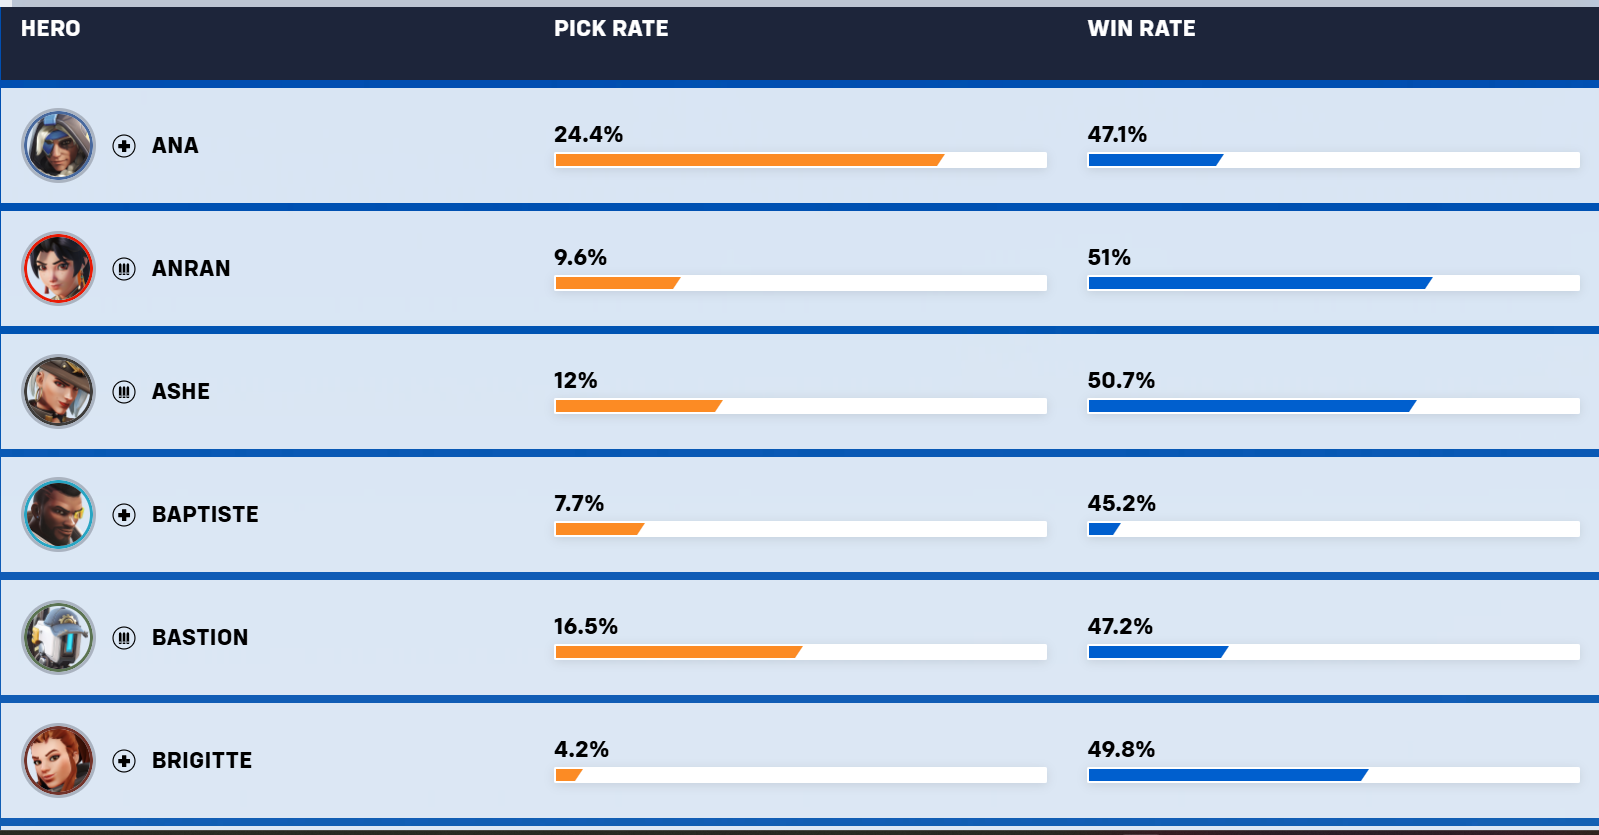

https://overwatch.fandom.com/wiki/Heroes?__cf_chl_tk=j6LDh6WIHo3V7nuOosL1iDN8QF0sj.sgTbChYXsdSDE-1775703251-1.0.1.1-DoPR7yzKku4o7qHvHMtXdivsEIAfjdjU9A5X3Gymcac
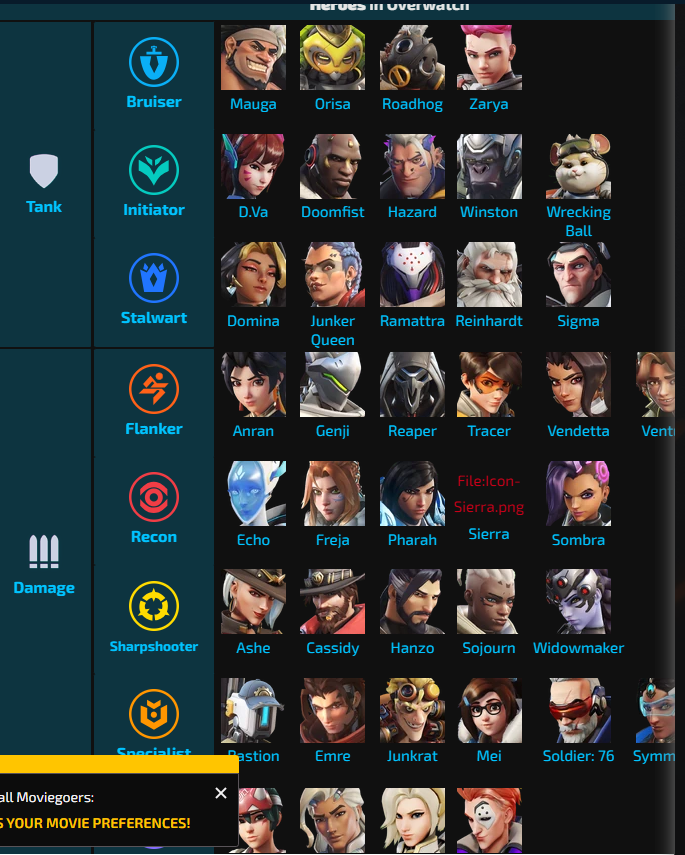
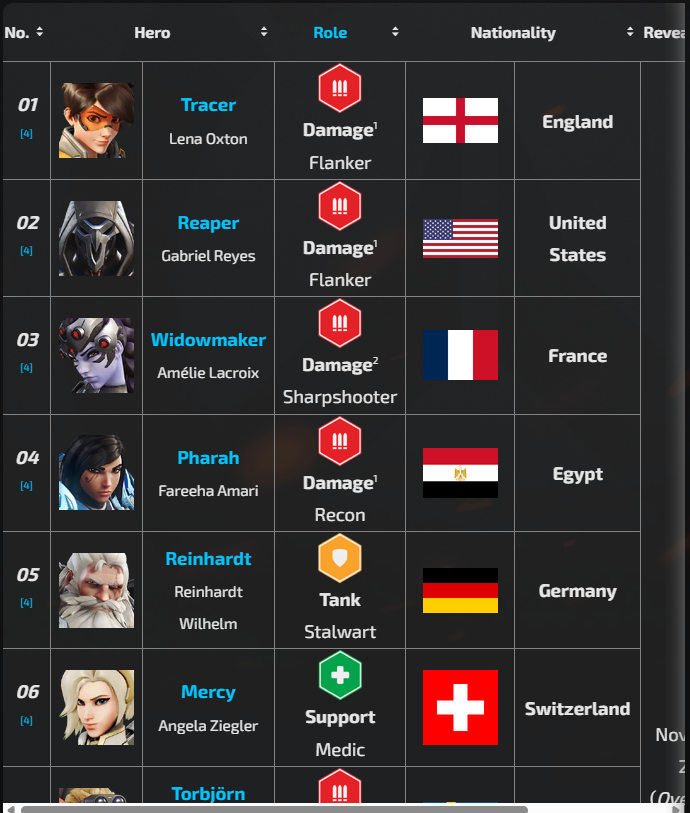